Importing packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.feature_selection import RFE

  1. Load Excel file

In [3]:
#file_path =   # Change this to your actual file path
df = pd.read_csv("walmart-sales-dataset-of-45stores.csv")

  2. Drop duplicates

In [4]:
df.drop_duplicates(inplace=True)

  3. Handle missing values with mean imputation

In [6]:
# Import necessary libraries if not already imported
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# Separate numeric and non-numeric columns
numeric_columns = df.select_dtypes(include=[np.number]).columns
non_numeric_columns = df.select_dtypes(exclude=[np.number]).columns

# Apply mean imputation only to numeric columns
if len(numeric_columns) > 0:
    imputer = SimpleImputer(strategy='mean')
    df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

# For non-numeric columns, you might want to use a different strategy
# For example, 'most_frequent' or 'constant'
if len(non_numeric_columns) > 0:
    non_numeric_imputer = SimpleImputer(strategy='most_frequent')
    df[non_numeric_columns] = non_numeric_imputer.fit_transform(df[non_numeric_columns])

4. Encode categorical variables using Label Encoding

In [7]:
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

5. Normalize using Min-Max Scaling

In [8]:
scaler = MinMaxScaler()
df[df.columns] = scaler.fit_transform(df)

6. Feature Selection using Wrapper Method (Recursive Feature Elimination)

 7. Define Features and Targets 

In [9]:
# Assuming the last column is the target variable and the rest are features
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

 8. Feature Selection via RFE

In [10]:
model = LinearRegression()
rfe = RFE(model, n_features_to_select=5)  # Change number of features as needed
rfe.fit(X, y)

RFE(estimator=LinearRegression(), n_features_to_select=5)

 9. Split into train (60%), validation (20%), test (20%)

In [11]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)  # 0.25 * 0.8 = 0.2

 10. Linear Regression Model

In [12]:
model = LinearRegression()

 11. Five-Fold Cross-Validation on training set

In [13]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
print(f"5-Fold CV R2 scores: {cv_scores}")
print(f"Mean R2 score: {np.mean(cv_scores):.4f}")

5-Fold CV R2 scores: [0.141556   0.16174733 0.17530762 0.14064398 0.19280199]
Mean R2 score: 0.1624


10. Train model

In [14]:
model.fit(X_train, y_train)

LinearRegression()

 12. Evaluate on validation set

In [15]:
y_val_pred = model.predict(X_val)
print("\nValidation Metrics:")
print(f"R2: {r2_score(y_val, y_val_pred):.4f}")
print(f"MSE: {mean_squared_error(y_val, y_val_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y_val, y_val_pred):.4f}")


Validation Metrics:
R2: 0.1331
MSE: 0.0276
RMSE: 0.1661
MAE: 0.1137


 13. Evaluate on test set

In [16]:
y_test_pred = model.predict(X_test)
print("\nTest Set Metrics:")
print(f"R2: {r2_score(y_test, y_test_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_test_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred):.4f}")


Test Set Metrics:
R2: 0.1656
MSE: 0.0273
RMSE: 0.1652
MAE: 0.1103


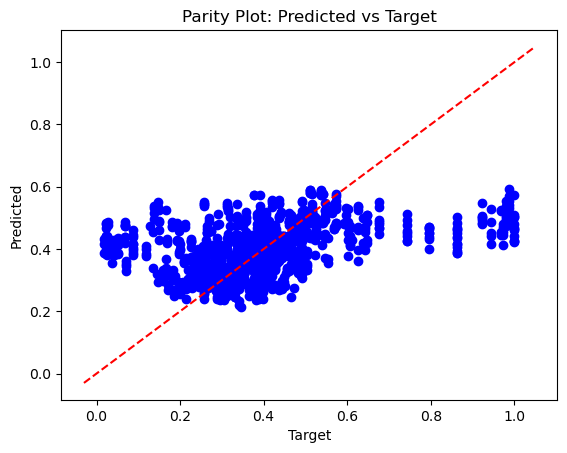

In [17]:
# Parity Plot: Predicted vs Target 

plt.scatter(y_test, y_test_pred, color ='b')

# Get current axes limits
xlim = plt.xlim()
ylim = plt.ylim()

# Calculate the range for the 45-degree line
min_val = min(xlim[0], ylim[0])
max_val = max(xlim[1], ylim[1])
line_range = np.array([min_val, max_val])

# Plot the 45-degree line (y=x)
plt.plot(line_range, line_range, color='red', linestyle='--', label='45-degree Line')

plt.title('Parity Plot: Predicted vs Target')
plt.xlabel('Target')
plt.ylabel('Predicted')
plt.show()